In [36]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
file_path = '/content/drive/MyDrive/yztaBootcamp/bankCustomerDataset.csv'

In [37]:
df = pd.read_csv(file_path)

print("="*50)
print("KEŞİFSEL VERİ ANALİZİ (EDA) ÇIKTILARI")
print("="*50)

print("\n Veri Seti Boyutu (Satır, Sütun):")
print(df.shape)

print("\n Eksik Değer Kontrolü :")
print(df.isnull().sum())

print("\n Kolonlar ve Veri Tipleri :")
print(df.info())

print("\n Temel İstatistiksel Özet :")
display(df.describe())


KEŞİFSEL VERİ ANALİZİ (EDA) ÇIKTILARI

 Veri Seti Boyutu (Satır, Sütun):
(10000, 18)

 Eksik Değer Kontrolü :
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

 Kolonlar ve Veri Tipleri :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [24]:
# Korelasyon matrisi için anlamsız (ID gibi) kolonları çıkarıp sadece sayısal olanları seçiyoruz
numeric_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['RowNumber', 'CustomerId'], errors='ignore')

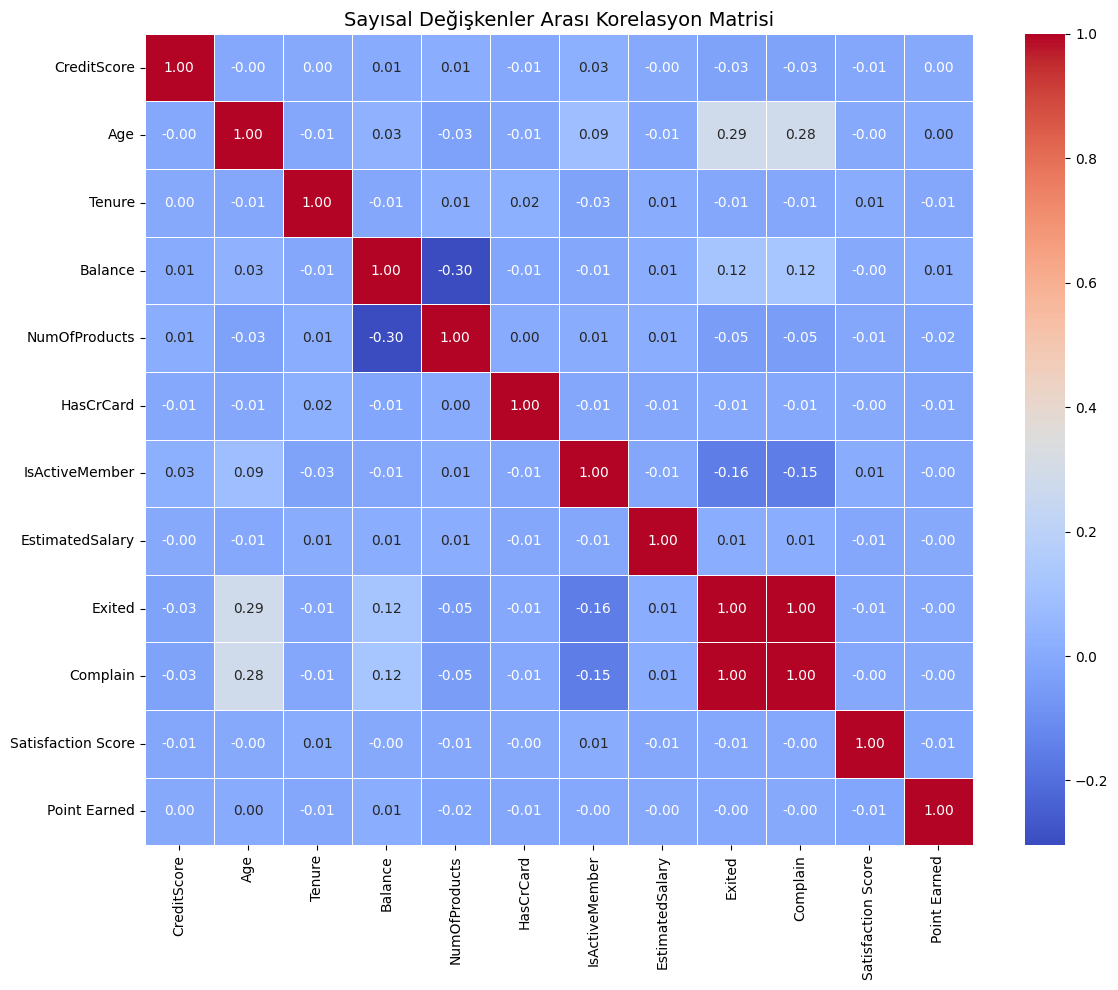

In [25]:
# GRAFİK 1: Sayısal Değişkenler Arası Korelasyon Matrisi
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi', fontsize=14)
plt.tight_layout()
plt.show()

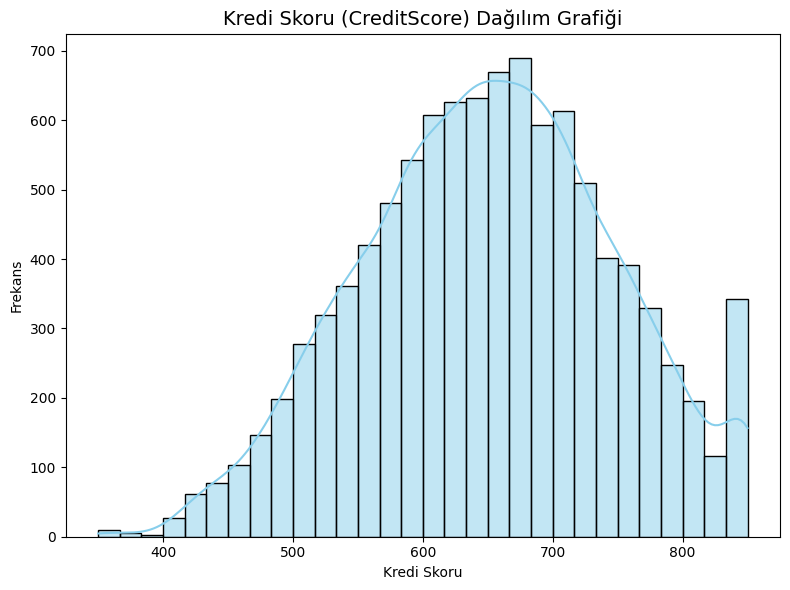

In [26]:
# GRAFİK 2: Kredi Skoru (CreditScore) Dağılım Histogramı
plt.figure(figsize=(8, 6))
sns.histplot(df['CreditScore'], bins=30, kde=True, color='skyblue')
plt.title('Kredi Skoru (CreditScore) Dağılım Grafiği', fontsize=14)
plt.xlabel('Kredi Skoru')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

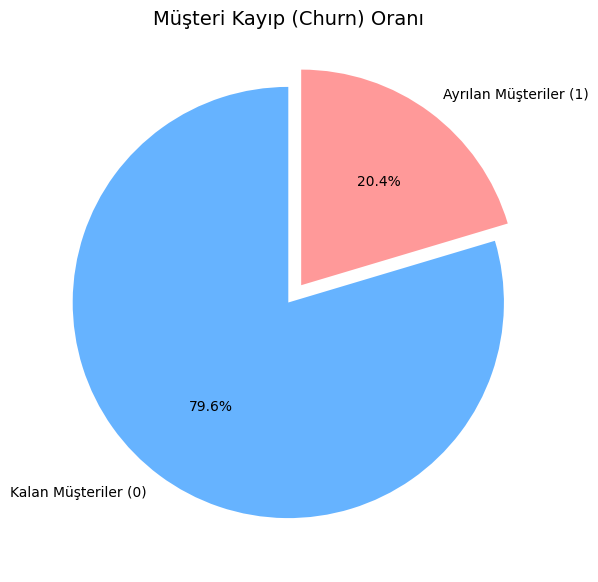

In [28]:
# GRAFİK 3: Müşteri Kaybı (Churn / Exited) Oranı - Pasta Grafiği
plt.figure(figsize=(7, 7))
churn_counts = df['Exited'].value_counts()
plt.pie(churn_counts, labels=['Kalan Müşteriler (0)', 'Ayrılan Müşteriler (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'], explode=(0, 0.1))
plt.title('Müşteri Kayıp (Churn) Oranı', fontsize=14)
plt.show()

/tmp/ipykernel_4899/1335729925.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Exited'] == 0]['Age'], label='Kalan', shade=True, color='blue')
/tmp/ipykernel_4899/1335729925.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Exited'] == 1]['Age'], label='Ayrılan', shade=True, color='red')


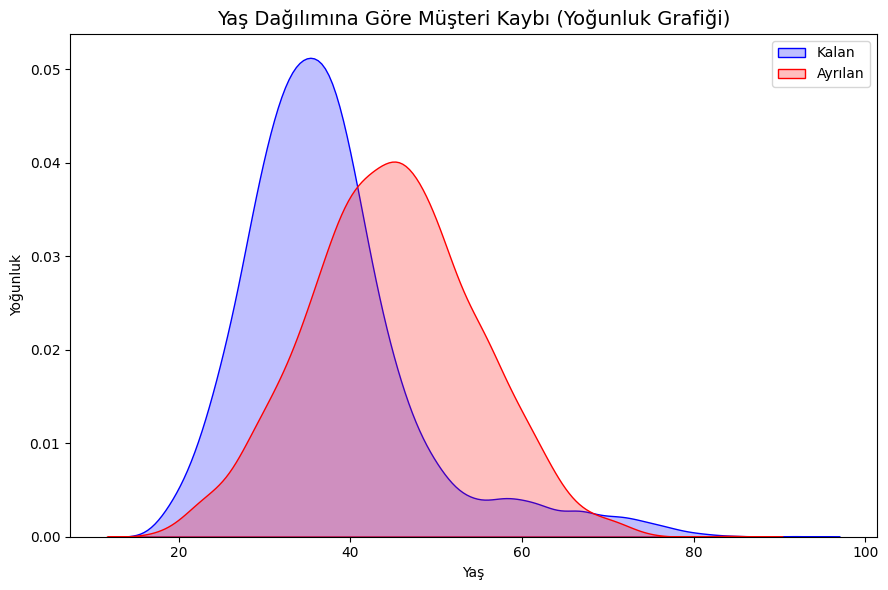

In [29]:
# GRAFİK 4: Yaş Dağılımı ve Müşteri Kaybı İlişkisi
plt.figure(figsize=(9, 6))
sns.kdeplot(data=df[df['Exited'] == 0]['Age'], label='Kalan', shade=True, color='blue')
sns.kdeplot(data=df[df['Exited'] == 1]['Age'], label='Ayrılan', shade=True, color='red')
plt.title('Yaş Dağılımına Göre Müşteri Kaybı (Yoğunluk Grafiği)', fontsize=14)
plt.xlabel('Yaş')
plt.ylabel('Yoğunluk')
plt.legend()
plt.tight_layout()
plt.show()

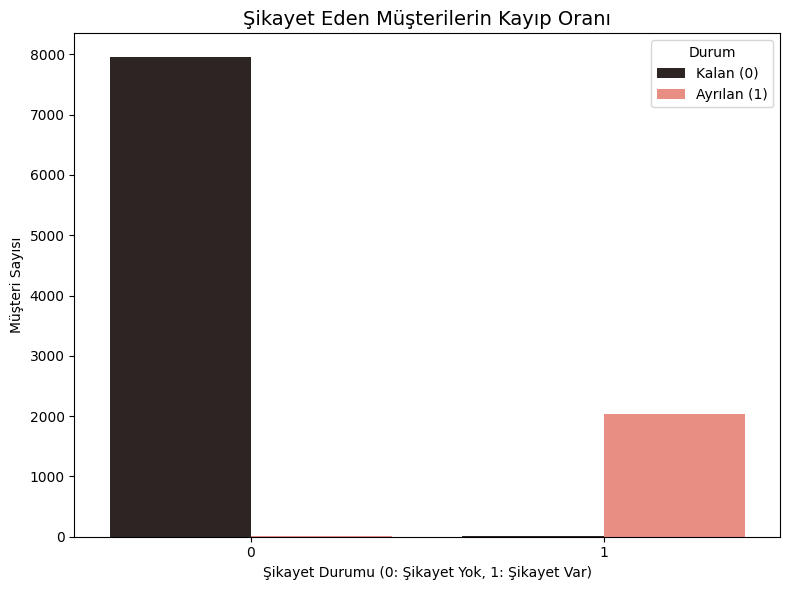

In [32]:
# GRAFİK 5: Şikayet Durumu (Complain) ve Müşteri Kaybı İlişkisi
plt.figure(figsize=(8, 6))
sns.countplot(x='Complain', hue='Exited', data=df, palette='dark:salmon')
plt.title('Şikayet Eden Müşterilerin Kayıp Oranı', fontsize=14)
plt.xlabel('Şikayet Durumu (0: Şikayet Yok, 1: Şikayet Var)')
plt.ylabel('Müşteri Sayısı')
plt.legend(title='Durum', labels=['Kalan (0)', 'Ayrılan (1)'])
plt.tight_layout()
plt.show()

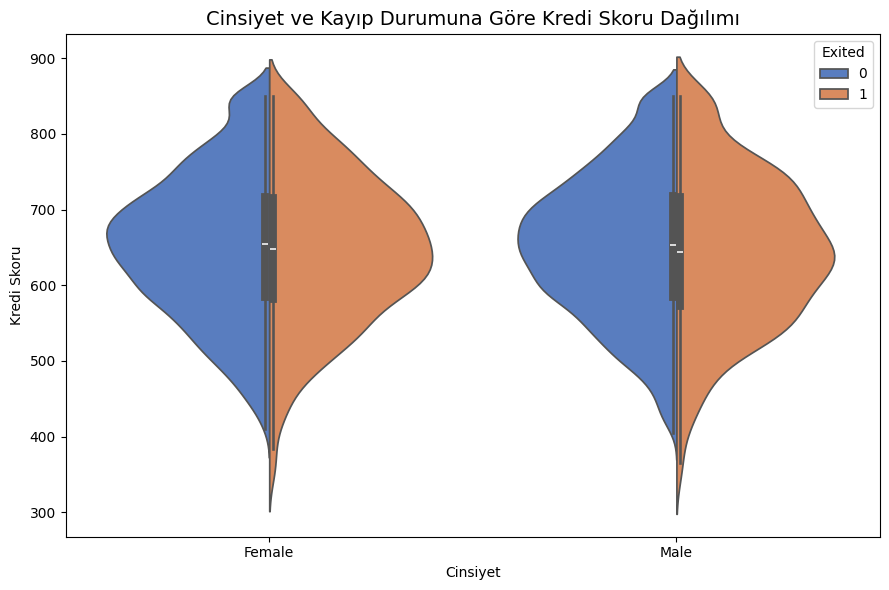

In [34]:
# GRAFİK 6: Cinsiyete Göre Kredi Skoru Dağılımı (Keman Grafiği - Violin Plot)
plt.figure(figsize=(9, 6))
sns.violinplot(x='Gender', y='CreditScore', hue='Exited', data=df, split=True, palette='muted')
plt.title('Cinsiyet ve Kayıp Durumuna Göre Kredi Skoru Dağılımı', fontsize=14)
plt.xlabel('Cinsiyet')
plt.ylabel('Kredi Skoru')
plt.tight_layout()
plt.show()